In [46]:
# ==========================================
# MODEL EVALUATION
# RideWise Customer Churn
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [ ]:
# ==========================================
# LOADING CORRECT MODELLING DATASET
# ==========================================

data_path = Path("../data/processed/rider_level_churn_dataset.csv")

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (10000, 48)


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,referred_by,is_referred,total_trips,avg_fare,...,tip_ratio,spend_per_day,session_intensity,app_usage_score,conversion_engagement_score,non_standard_trip_rate,surge_fare_interaction,loyalty_spend_interaction,age_group,is_churned
0,R00000,2025-01-24 00:00:00+00:00,Bronze,34.729629,Nairobi,5.0,R00001,1,25,14.642000,...,0.011009,3.936022,0.043011,276.000000,9.75,0.520000,16.047632,98.400538,26-35,0
1,R00001,2024-09-09 00:00:00+00:00,Bronze,34.571020,Nairobi,4.7,Unknown,0,14,12.895000,...,0.004210,0.784913,0.013043,465.777778,0.00,0.571429,13.816071,10.988783,26-35,0
2,R00002,2024-09-07 00:00:00+00:00,Bronze,47.133960,Lagos,4.2,Unknown,0,24,15.791250,...,0.013747,1.633578,0.012931,573.000000,0.00,0.291667,18.817906,39.205862,46-60,0
3,R00003,2025-03-17 00:00:00+00:00,Bronze,41.658628,Nairobi,4.9,Unknown,0,9,13.496667,...,0.007162,2.962683,0.073171,125.555556,0.00,1.000000,15.596148,26.664146,36-45,1
4,R00004,2024-08-20 00:00:00+00:00,Silver,40.681709,Lagos,3.9,R00002,1,16,16.776875,...,0.034944,1.073720,0.008000,42.500000,0.00,0.687500,21.180805,17.179520,36-45,0


In [48]:
# ==========================================
# DEFINE TARGET AND FEATURES
# Must match Notebook 05
# ==========================================

target = "is_churned"

drop_cols = [
    "is_churned",
    "user_id",
    "signup_date",
    "referred_by"
]

y = df[target]
X = df.drop(columns=drop_cols, errors="ignore")

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution percentage:")
print(y.value_counts(normalize=True) * 100)

Feature shape: (10000, 44)
Target shape: (10000,)

Target distribution:
is_churned
0    8114
1    1886
Name: count, dtype: int64

Target distribution percentage:
is_churned
0    81.14
1    18.86
Name: proportion, dtype: float64


In [49]:
# ==========================================
# TRAIN-TEST SPLIT
# Must match Notebook 05
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 44)
X_test: (2000, 44)
y_train: (8000,)
y_test: (2000,)


In [50]:
# ==========================================
# LOAD BEST SAVED MODEL AND THRESHOLD
# ==========================================

model_dir = Path("../models")

best_model = joblib.load(model_dir / "churn_prediction_model.pkl")
best_threshold = joblib.load(model_dir / "churn_prediction_threshold.pkl")

best_threshold = round(float(best_threshold), 2)

print("Best model loaded successfully.")
print("Best threshold:", best_threshold)
print("Model type:", type(best_model))

Best model loaded successfully.
Best threshold: 0.45
Model type: <class 'sklearn.pipeline.Pipeline'>


In [51]:
# ==========================================
# MAKE PREDICTIONS
# ==========================================

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= best_threshold).astype(int)

print("Predictions completed.")
print("Predicted Not Churn:", (y_pred == 0).sum())
print("Predicted Churn:", (y_pred == 1).sum())

Predictions completed.
Predicted Not Churn: 965
Predicted Churn: 1035


In [52]:
# ==========================================
# FINAL MODEL EVALUATION METRICS
# ==========================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

evaluation_results = pd.DataFrame([
    {
        "Model": "Final Churn Model",
        "Threshold": best_threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Average Precision": avg_precision
    }
])

evaluation_results

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Final Churn Model,0.45,0.549,0.246377,0.676393,0.36119,0.60855,0.255894


In [53]:
# ==========================================
# PRINT FINAL METRICS
# ==========================================

print("Final Model Evaluation")
print("----------------------------------------")
print(f"Threshold:          {best_threshold}")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1 Score:           {f1:.4f}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"Average Precision:  {avg_precision:.4f}")

Final Model Evaluation
----------------------------------------
Threshold:          0.45
Accuracy:           0.5490
Precision:          0.2464
Recall:             0.6764
F1 Score:           0.3612
ROC-AUC:            0.6085
Average Precision:  0.2559


In [54]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("Classification Report")
print("----------------------------------------")
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report
----------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.52      0.65      1623
           1       0.25      0.68      0.36       377

    accuracy                           0.55      2000
   macro avg       0.56      0.60      0.51      2000
weighted avg       0.76      0.55      0.60      2000



Confusion Matrix:
[[843 780]
 [122 255]]


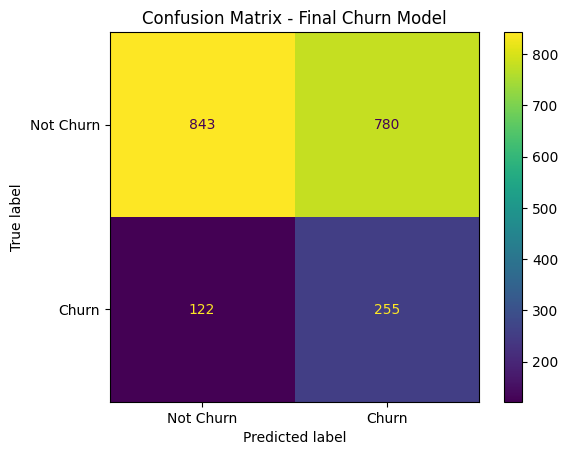

In [55]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Final Churn Model")
plt.show()

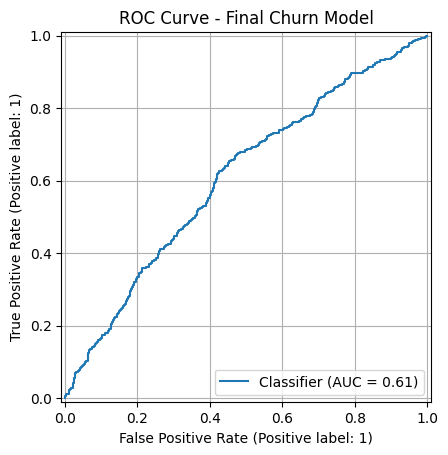

In [56]:
# ==========================================
# ROC CURVE
# ==========================================

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Final Churn Model")
plt.grid(True)
plt.show()

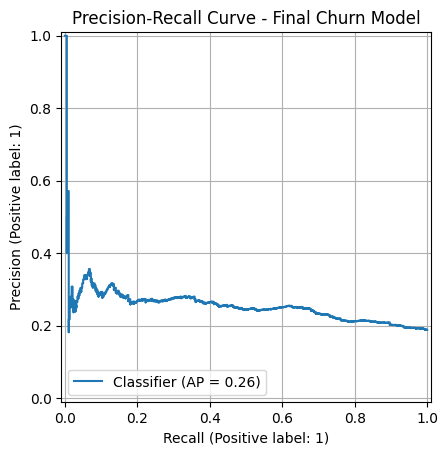

In [57]:
# ==========================================
# PRECISION-RECALL CURVE
# ==========================================

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall Curve - Final Churn Model")
plt.grid(True)
plt.show()

In [58]:
# ==========================================
# THRESHOLD EVALUATION
# ==========================================

thresholds = np.arange(0.20, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:
    temp_pred = (y_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(float(threshold), 2),
        "Accuracy": accuracy_score(y_test, temp_pred),
        "Precision": precision_score(y_test, temp_pred, zero_division=0),
        "Recall": recall_score(y_test, temp_pred, zero_division=0),
        "F1 Score": f1_score(y_test, temp_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.45,0.5490,0.246377,0.676393,0.361190,0.60855
1,0.40,0.4380,0.217260,0.761273,0.338045,0.60855
2,0.35,0.3595,0.209512,0.864721,0.337300,0.60855
3,0.30,0.3020,0.201523,0.912467,0.330134,0.60855
4,0.50,0.6175,0.244737,0.493369,0.327177,0.60855
5,0.25,0.2505,0.194111,0.944297,0.322026,0.60855
6,0.20,0.2195,0.191988,0.978780,0.321009,0.60855
7,0.55,0.7095,0.278261,0.339523,0.305854,0.60855
8,0.60,0.7540,0.267206,0.175066,0.211538,0.60855


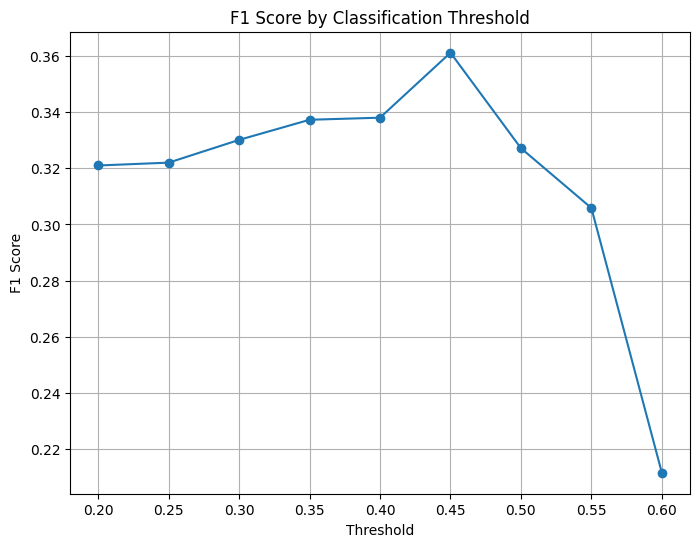

In [59]:
# ==========================================
# PLOT F1 SCORE BY THRESHOLD
# ==========================================

plt.figure(figsize=(8, 6))
plt.plot(threshold_df["Threshold"], threshold_df["F1 Score"], marker="o")

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score by Classification Threshold")
plt.grid(True)
plt.show()

In [60]:
# ==========================================
# SAVE EVALUATION RESULTS
# ==========================================

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

evaluation_results.to_csv(
    reports_dir / "final_model_evaluation_results.csv",
    index=False
)

threshold_df.to_csv(
    reports_dir / "threshold_evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [61]:
# ==========================================
# SAVE FINAL PREDICTIONS
# ==========================================

predictions_df = X_test.copy()
predictions_df["actual_churn"] = y_test.values
predictions_df["predicted_churn"] = y_pred
predictions_df["churn_probability"] = y_proba
predictions_df["threshold"] = best_threshold

predictions_df.to_csv(
    reports_dir / "final_model_predictions.csv",
    index=False
)

print("Predictions saved successfully.")
predictions_df.head()

Predictions saved successfully.


,loyalty_status,age,city,avg_rating_given,is_referred,total_trips,avg_fare,total_fare,avg_surge,avg_tip,...,app_usage_score,conversion_engagement_score,non_standard_trip_rate,surge_fare_interaction,loyalty_spend_interaction,age_group,actual_churn,predicted_churn,churn_probability,threshold
1944,Platinum,34.975741,Cairo,3.5,0,18,16.534444,297.62,1.150000,0.751667,...,305.920000,16.352000,0.611111,19.014611,81.169091,26-35,0,1,0.559646,0.45
6353,Bronze,31.263462,Lagos,5.0,0,27,13.558889,366.09,1.092593,0.530741,...,879.666667,27.538889,0.481481,14.814342,112.323068,26-35,0,0,0.223144,0.45
3774,Platinum,41.388087,Cairo,4.5,0,16,13.671250,218.74,1.025000,1.552500,...,148.400000,19.008000,0.437500,14.013031,10.801975,36-45,0,1,0.657091,0.45
3478,Silver,23.792948,Cairo,4.2,0,26,15.500000,403.00,1.134615,0.818462,...,105.000000,0.000000,0.461538,17.586538,34.354098,18-25,0,0,0.203967,0.45
8464,Bronze,49.462795,Cairo,4.9,1,23,14.771304,339.74,1.195652,0.524783,...,497.812500,0.000000,0.652174,17.661342,38.875721,46-60,0,0,0.392414,0.45
